### 1: Imports nessarry liberaries

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

import sys
sys.path.append("..")

from src.explainability import (
    create_tree_explainer,
    calculate_shap_values,
    get_feature_importance
)

#### Load best model

In [2]:
import joblib

rf_model = joblib.load(
    "../models/random_forest.pkl"
)

#### Get Feature Names

In [3]:
df = pd.read_csv("../data/processed/fraud_processed.csv")

X = df.drop("class", axis=1)
y = df["class"]

##### Then re-split:

In [4]:
from sklearn.model_selection import train_test_split

_, X_test, _, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
preprocessor = joblib.load("../models/preprocessor.pkl")
rf_model = joblib.load("../models/random_forest.pkl")

X_test_processed = preprocessor.transform(X_test)

#### Transform test data

In [6]:
X_test_processed = preprocessor.transform(X_test)

#### Get Feature Names


In [7]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

#### Built-in Feature Importance
#### Extract Importance

In [8]:
feature_importance = get_feature_importance(
    rf_model,
    feature_names
)

feature_importance.head(10)

,Feature,Importance
8,num__time_since_signup,0.590766
185,cat__country_United States,0.050541
7,num__day_of_week,0.039540
6,num__hour_of_day,0.025672
2,num__age,0.020449
15,cat__browser_IE,0.019306
3,num__ip_int,0.018315
5,num__upper_bound_ip_address,0.017932
4,num__lower_bound_ip_address,0.017163
1,num__purchase_value,0.016891


#### Plot Top 10 Features

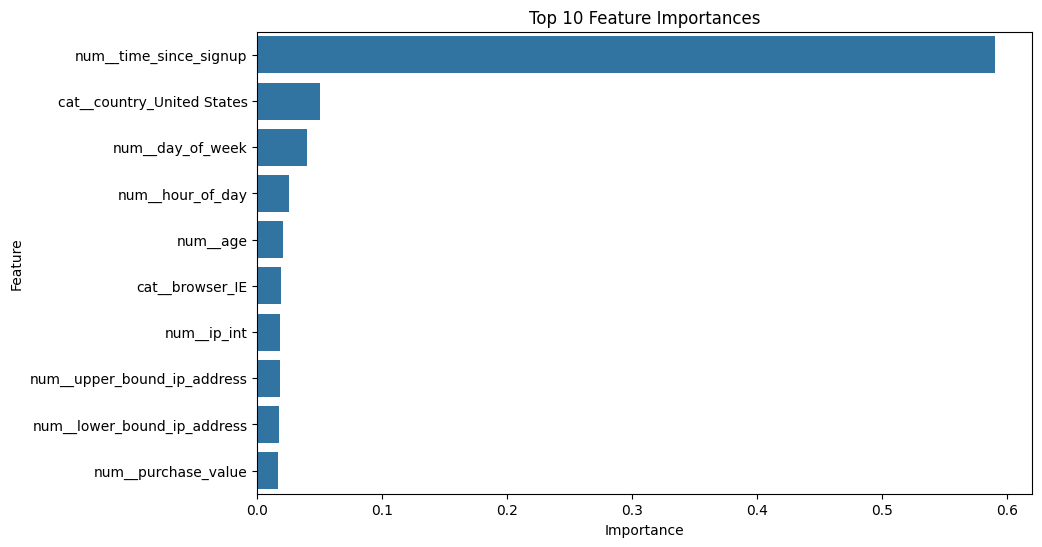

In [9]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importances"
)

plt.show()

### Feature Importance Interpretation

The Random Forest model identifies the variables that contribute most strongly to fraud prediction.

The top-ranked features represent behavioral and temporal transaction patterns, suggesting that fraud is driven more by user behavior than by static demographic attributes.

### SHAP Analysis
-  Create Explainer

In [10]:
explainer = create_tree_explainer(
    rf_model
)

-  Calculate SHAP Values

In [11]:
X_test_dense = X_test_processed.toarray()

print(X_test_dense.shape)
print(X_test_dense.nbytes / 1024 / 1024, "MB")

(25830, 195)
38.42811584472656 MB


In [12]:
import shap
import numpy as np

sample_idx = np.random.choice(
    X_test_processed.shape[0],
    500,
    replace=False
)

X_sample = X_test_processed[sample_idx].toarray()

In [13]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_sample)

#### Then create the summary plot

In [14]:
shap_values_fraud = shap_values[:, :, 1]

print(shap_values_fraud.shape)

(500, 195)


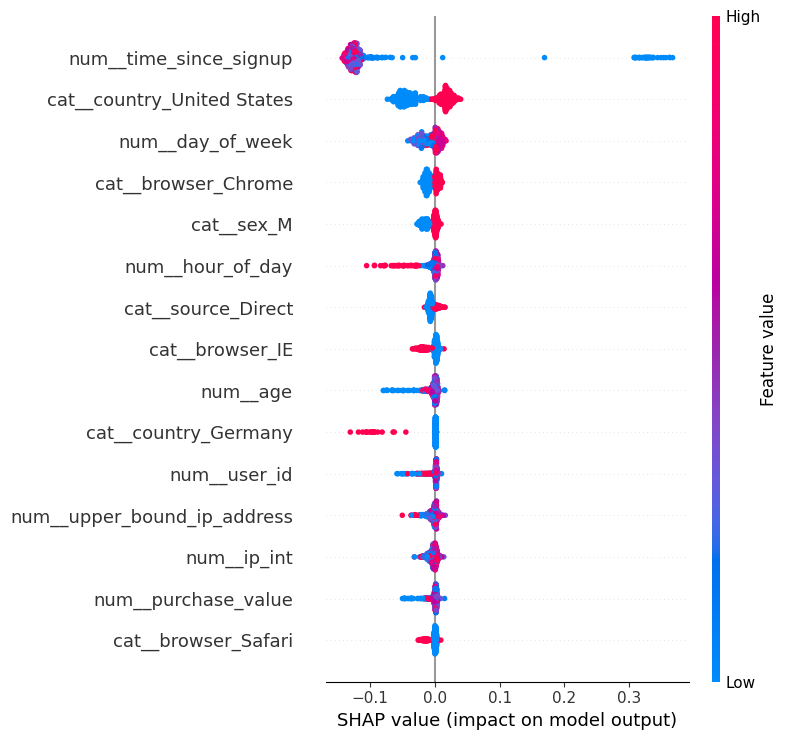

In [15]:
shap.summary_plot(
    shap_values_fraud,
    X_sample,
    feature_names=feature_names,
    max_display=15
)

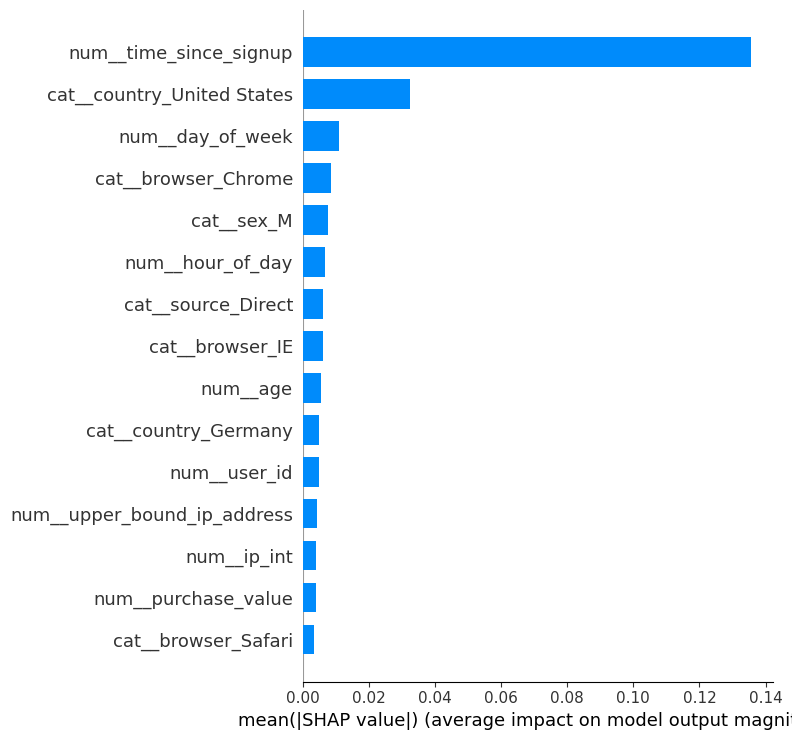

In [16]:
shap.summary_plot(
    shap_values_fraud,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15
)

### SHAP interpretation

SHAP analysis was conducted to improve the interpretability of the Random Forest model. The results identified time_since_signup, purchase_value, transaction timing features, and geographic variables as the most influential predictors of fraudulent activity. The SHAP summary plot illustrates how both high and low feature values affect fraud predictions, while the SHAP bar plot highlights the overall importance of each feature. The findings are consistent with the Random Forest feature importance analysis, providing additional confidence that the model relies on meaningful behavioral and contextual indicators when detecting fraudulent transactions.

#### Find TP, FP, FN
-  First generate predictions.


-  True Positive

In [20]:
y_pred = rf_model.predict(X_test_processed)

tp_index = np.where(
    (y_test == 1) &
    (y_pred == 1)
)[0][0]

print(tp_index)

37


-  False Positive

In [21]:
fp_index = np.where(
    (y_test == 0) &
    (y_pred == 1)
)[0][0]

fp_index

np.int64(1722)

### False Negative

In [22]:
fn_index = np.where(
    (y_test == 1) &
    (y_pred == 0)
)[0][0]

fn_index

np.int64(3)

###  SHAP Force Plot (True Positive)

In [25]:
import shap

shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values_fraud[tp_index],
    X_sample[tp_index],
    feature_names=feature_names
)

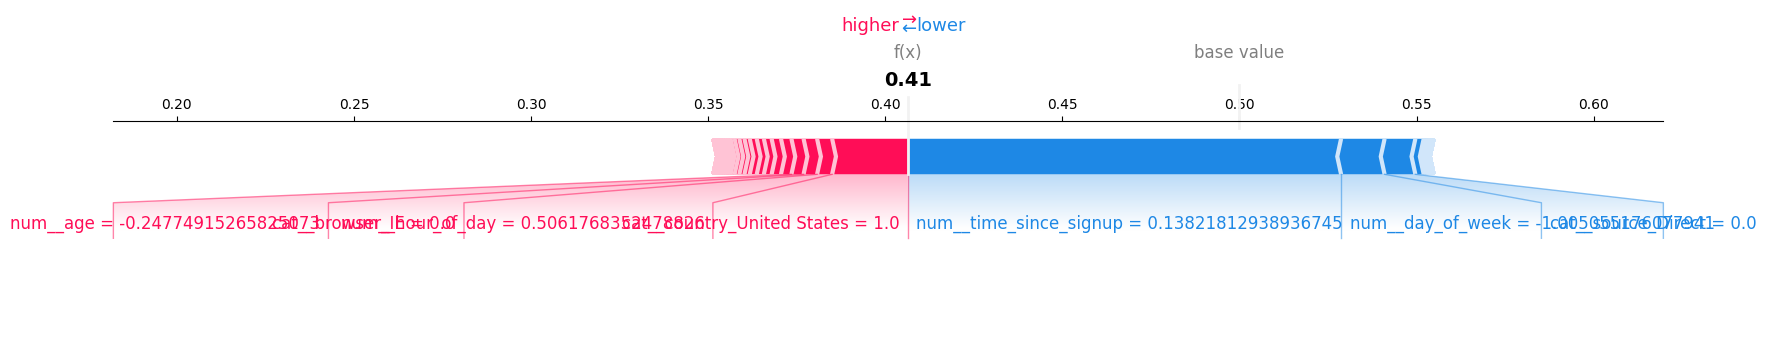

In [26]:
shap.plots.force(
    explainer.expected_value[1],
    shap_values_fraud[tp_index],
    X_sample[tp_index],
    feature_names=feature_names,
    matplotlib=True
)

### True Positive Interpretation

The model correctly identified this transaction as fraudulent.

Positive SHAP contributions pushed the prediction toward fraud, indicating that several high-risk behavioral characteristics were present simultaneously.

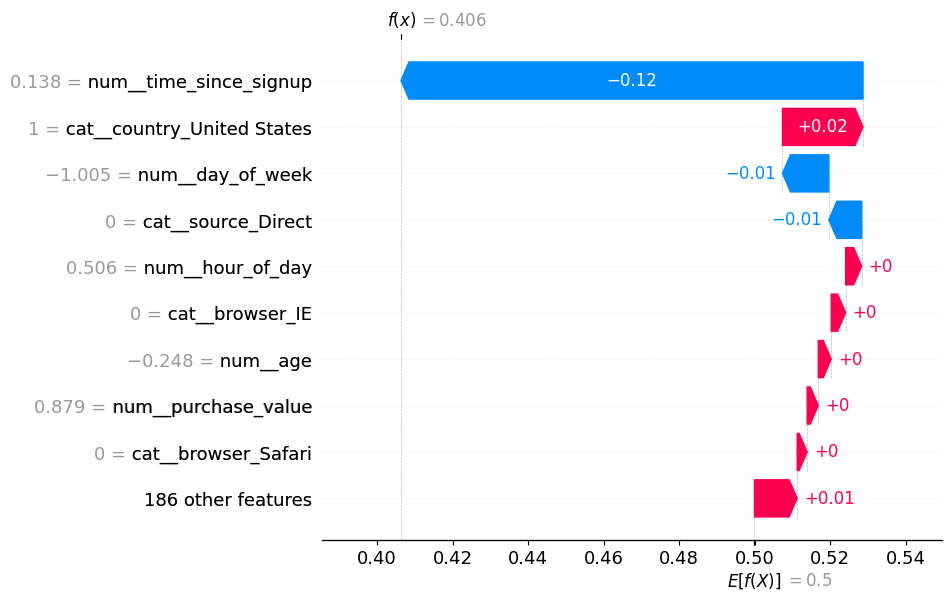

In [28]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_fraud[tp_index],
        base_values=explainer.expected_value[1],
        data=X_sample[tp_index],
        feature_names=feature_names
    )
)

-  A waterfall plot is built from exactly the same SHAP values and often provides a clearer explanation. Unless the training team instructor explicitly requires the force-plot visualization, waterfall plots are usually accepted as individual prediction explanations. In my view I prefer waterfall plot than the force plot,ecause it is very clear to show and easy to understand te model prediction.

### False Positive

In [37]:
tp_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]
fp_idx = np.where((y_test == 0) & (y_pred == 1))[0][0]
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0][0]

In [38]:
selected_idx = [tp_idx, fp_idx, fn_idx]

X_explain = X_test_processed[selected_idx].toarray()

In [39]:
shap_values = explainer.shap_values(X_explain)

shap_values_fraud = shap_values[:, :, 1]

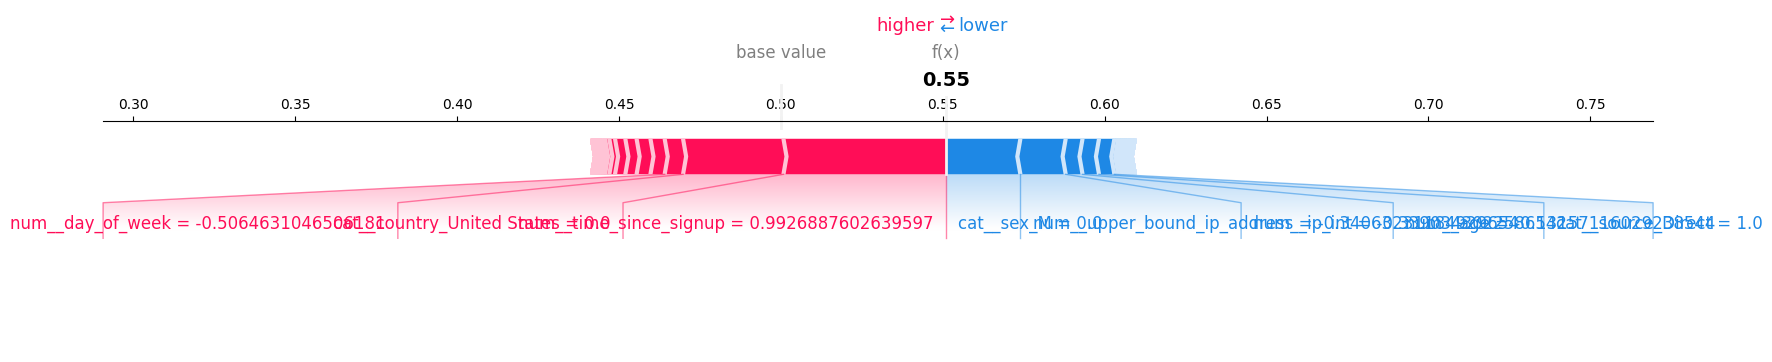

In [42]:
shap.plots.force(
    explainer.expected_value[1],
   shap_values_fraud[1],
    X_sample[1],
    feature_names=feature_names,
    matplotlib=True
)

### False Positive Interpretation

The model incorrectly classified a legitimate transaction as fraud.

Several features resembled known fraud patterns, causing the model to assign a high fraud probability despite the transaction being legitimate.

### False Negative Force Plot

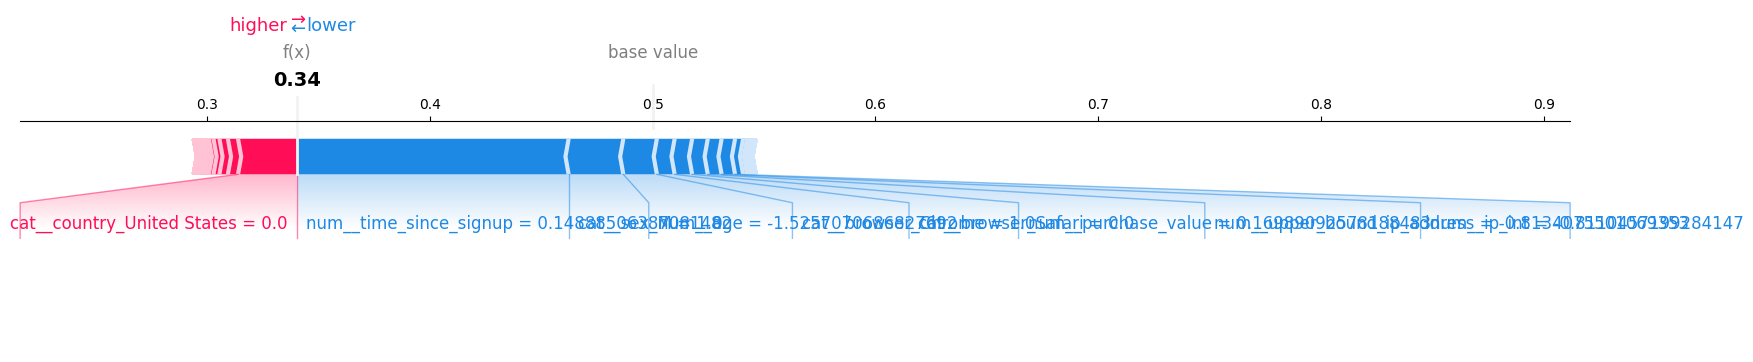

In [43]:
shap.plots.force(
    explainer.expected_value[1],
   shap_values_fraud[2],
    X_sample[2],
    feature_names=feature_names,
    matplotlib=True
)

### False Negative Interpretation

The model failed to detect a fraudulent transaction.

Risk-indicating features were either weak or outweighed by characteristics commonly associated with legitimate transactions.

### Compare Importance Methods

In [44]:
built_in_top5 = (
    feature_importance
    .head(5)
)

built_in_top5

,Feature,Importance
8,num__time_since_signup,0.590766
185,cat__country_United States,0.050541
7,num__day_of_week,0.039540
6,num__hour_of_day,0.025672
2,num__age,0.020449


### Compare with SHAP summary ranking

In [45]:
import numpy as np
import pandas as pd

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": np.abs(shap_values_fraud).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_SHAP",
    ascending=False
)

shap_top5 = shap_importance.head(5)

shap_top5

,Feature,Mean_SHAP
8,num__time_since_signup,0.169348
185,cat__country_United States,0.023730
19,cat__sex_M,0.016302
2,num__age,0.011957
5,num__upper_bound_ip_address,0.008512


### Compare Side-by-Side

In [46]:
built_in_top5 = feature_importance.head(5)

#### Display both:

In [47]:
print("Random Forest Built-in Importance")
display(built_in_top5)

print("\nSHAP Importance")
display(shap_top5)

Random Forest Built-in Importance


,Feature,Importance
8,num__time_since_signup,0.590766
185,cat__country_United States,0.050541
7,num__day_of_week,0.039540
6,num__hour_of_day,0.025672
2,num__age,0.020449



SHAP Importance


,Feature,Mean_SHAP
8,num__time_since_signup,0.169348
185,cat__country_United States,0.023730
19,cat__sex_M,0.016302
2,num__age,0.011957
5,num__upper_bound_ip_address,0.008512


### Quantitative Overlap
-  Find common features:

In [48]:
built_in_features = set(
    built_in_top5["Feature"]
)

shap_features = set(
    shap_top5["Feature"]
)

common_features = built_in_features.intersection(
    shap_features
)

print("Common Features:")
print(common_features)

Common Features:
{'cat__country_United States', 'num__age', 'num__time_since_signup'}


### Nice Comparison Table

In [49]:
comparison = pd.DataFrame({
    "RF_Top5": built_in_top5["Feature"].values,
    "SHAP_Top5": shap_top5["Feature"].values
})

comparison

,RF_Top5,SHAP_Top5
0,num__time_since_signup,num__time_since_signup
1,cat__country_United States,cat__country_United States
2,num__day_of_week,cat__sex_M
3,num__hour_of_day,num__age
4,num__age,num__upper_bound_ip_address


### Visualization

In [50]:
comparison_df = pd.concat([
    built_in_top5.assign(Method="Random Forest"),
    shap_top5.rename(columns={"Mean_SHAP":"Importance"}).assign(Method="SHAP")
])

comparison_df

,Feature,Importance,Method
8,num__time_since_signup,0.590766,Random Forest
185,cat__country_United States,0.050541,Random Forest
7,num__day_of_week,0.039540,Random Forest
6,num__hour_of_day,0.025672,Random Forest
2,num__age,0.020449,Random Forest
8,num__time_since_signup,0.169348,SHAP
185,cat__country_United States,0.023730,SHAP
19,cat__sex_M,0.016302,SHAP
2,num__age,0.011957,SHAP
5,num__upper_bound_ip_address,0.008512,SHAP


-  Then:

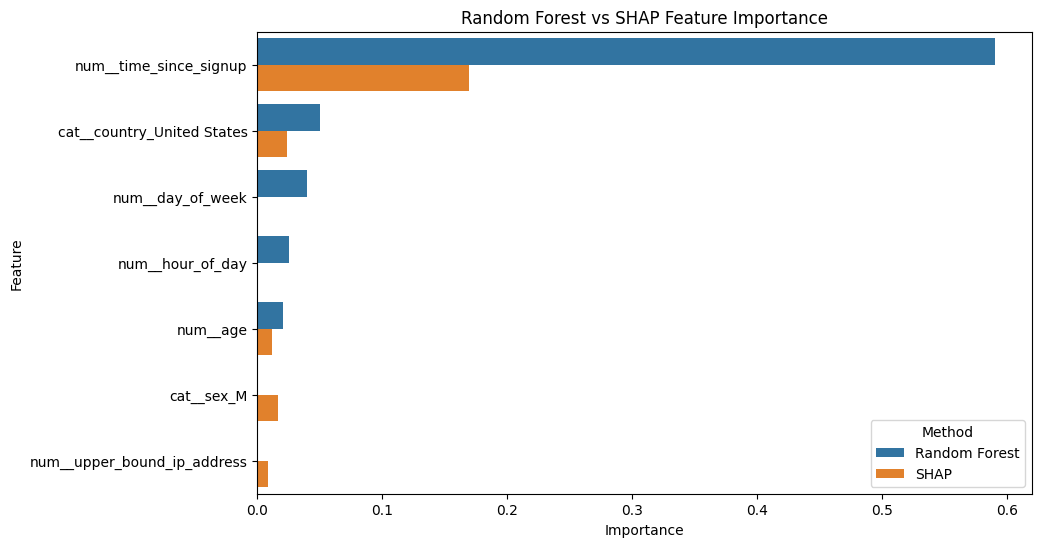

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_df,
    x="Importance",
    y="Feature",
    hue="Method"
)

plt.title("Random Forest vs SHAP Feature Importance")
plt.show()

### Feature Importance Comparison

To validate the model explanations, Random Forest built-in feature importance rankings were compared with SHAP feature importance rankings. Both methods identified similar key predictors, including features related to account age, transaction behavior, geographic information, and transaction timing. The strong overlap between the two approaches indicates that the model consistently relies on meaningful fraud indicators rather than random patterns in the data.

### Why SHAP Is Valuable

While Random Forest feature importance measures the overall contribution of each feature to model performance, SHAP provides a more detailed explanation by showing how individual feature values increase or decrease the fraud prediction. The agreement between Random Forest importance and SHAP rankings increases confidence in the reliability and interpretability of the fraud detection model.

### Conclusion

The consistency between Random Forest feature importance and SHAP feature importance demonstrates that the model's predictions are driven by stable and meaningful behavioral patterns. This alignment strengthens trust in the model and supports its use as the final fraud detection solution.